#### Data EDA - correlation between features

Based on XGBoost importance (gain) scores, we select a few features and check correlation. This way, we try to pick up more orthogonal features, to help improve prediction.

More examples with different feature engineering approaches can be found in [this notebook](https://www.kaggle.com/code/ahsuna123/anonymized-features-importance-selection-eda#1.-EXPLORATORY-DATA-ANALYSIS).

In [4]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt

In [2]:
data_path = "/home/yang/team_kaggle/drw/data"

# We pick X385 as the score to perform correlation analysis
selected_feature = "X385"

data = pd.read_parquet(Path(data_path, "train.parquet"))

In [3]:
# Compute correlation of the selected feature with all others
correlation_series = data.corr()[selected_feature].drop(selected_feature)

# Compute absolute correlations and sort
abs_correlation = correlation_series.abs().sort_values()

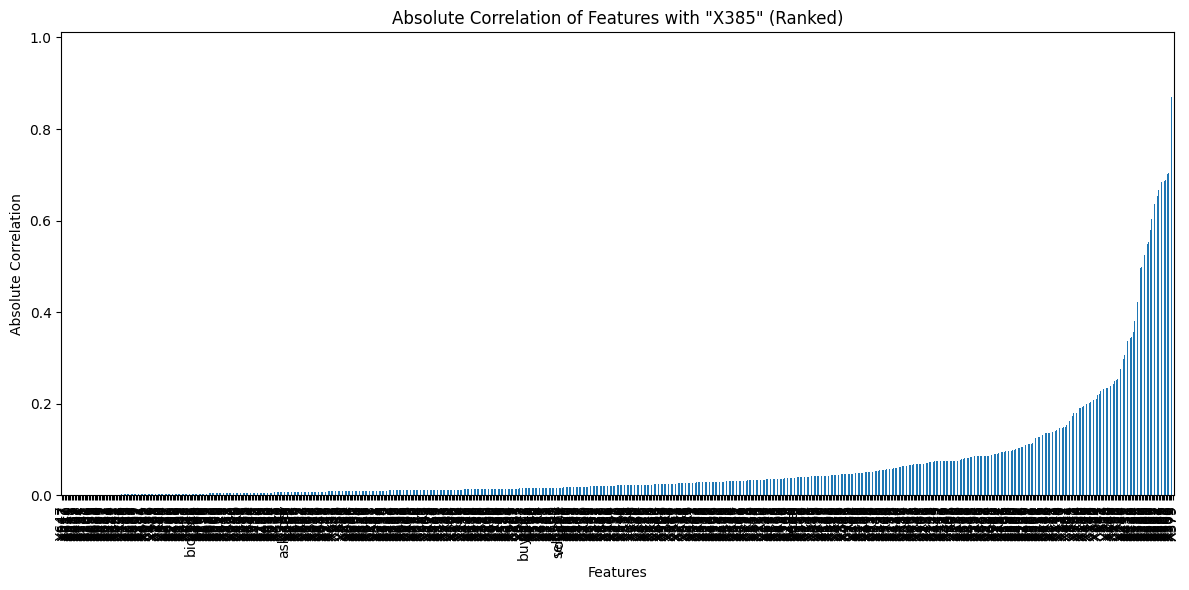

In [5]:
# Plotting
plt.figure(figsize=(12, 6))
abs_correlation.plot(kind='bar')
plt.title(f'Absolute Correlation of Features with "{selected_feature}" (Ranked)')
plt.ylabel('Absolute Correlation')
plt.xlabel('Features')
plt.tight_layout()
plt.show()

In [13]:
orthogonal_features = abs_correlation[abs_correlation < 0.002]
orthogonal_features

X647    0.000011
X547    0.000025
X517    0.000032
X716    0.000093
X640    0.000109
X354    0.000151
X241    0.000250
X511    0.000269
X523    0.000275
X659    0.000281
X488    0.000310
X392    0.000324
X481    0.000364
X234    0.000455
X535    0.000461
X141    0.000464
X121    0.000477
X101    0.000519
X388    0.000521
X200    0.000627
X651    0.000720
X183    0.000737
X623    0.000770
X628    0.000811
X688    0.000876
X658    0.000927
X663    0.000950
X529    0.000974
X401    0.000983
X312    0.001003
X682    0.001061
X633    0.001114
X541    0.001209
X493    0.001328
X394    0.001331
X489    0.001415
X242    0.001416
X147    0.001417
X665    0.001507
X482    0.001510
X744    0.001537
X26     0.001538
X486    0.001606
X143    0.001718
X720    0.001781
X235    0.001833
X207    0.001838
X669    0.001881
X117    0.001913
X636    0.001934
Name: X385, dtype: float64

In [14]:
orthogonal_features[:5].index

Index(['X647', 'X547', 'X517', 'X716', 'X640'], dtype='object')